# BEE 4750 Homework 1: Introduction to Using Julia

**Name**: Jinrong Yang 

**ID**: jy2256

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [219]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Downloads/Cornell/BEE 5750/bee4750-hw1-jy`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [220]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [221]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [222]:
function minimum(array)
    # initialize the minimum value counter
    min_value = array[1]
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


If all the values in the array are greater than 0, only an incorrect minimum value 0 will be obtained. Thus, I believe it is better to initialize the minimum value counter as the first element of the array.

What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [223]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  class_average = mean(grades)
  return class_average
end

@show class_average(student_grades);

class_average(student_grades) = 94.4


Average grade is not defined in this scope, so this will throw an error. Thus, I deleted it and replace with class_average(student_grades).

What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [224]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(Bool, n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) > 10) # win if sum of dice > = 11
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.502


From the error message we can learn that Julia cannot find a method for the setindex!. So I googled and found Website https://docs.julialang.org/en/v1/base/collections/#Base.setindex! From the website i learned that zero(n_trials) creates a zero value (integer 0) of the same type as n_trials and zeros(Bool, n_trials) creates a Boolean type array of length n_trials (all elements are initially false). The former generates a single number, while the latter generates a container that can be indexed and accessed.

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [225]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect .- m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [0.41919142411294885, -0.04477120169153992, -0.15987063495003362, -0.3165390583665356, -0.04345183269168251, 0.4600428661267356, -0.4814808404373695, 0.05265958609672772, -0.019033198532207418, 0.11752715148103854, -0.2530763598508532, -0.3987461186978969, -0.4051668577883766, -0.14537708102382318, -0.021518846454485097, 0.2393846697392613, -0.13828803455335292, 0.28932439329980286, -0.44190436643288566, -0.41462031768210295, -0.1481768399620188, -0.4467685839176895, 0.16354702958537648, -0.324893449617489, -0.22436376824831783, 0.18691945805247367, -0.2843753736563317, 0.30832500598057266, 0.2757047181327851, 0.44059511305789445, 0.12832592230812423, 0.1935791502153814, 0.2896691235161918, -0.05389047441266104, 0.1218772930619838, -0.24482626621372394, 0.22316484875624798, 0.4597763846856109, -0.33758006386107464, 0.19126011359930628, -0.3305504301513418, -0.20836963537351572, 0.4435549655840101, 0.14379124696474477, 0.3902589386802747, -0.2551400209756388, 

1000-element Vector{Float64}:
  0.41919142411294885
 -0.04477120169153992
 -0.15987063495003362
 -0.3165390583665356
 -0.04345183269168251
  0.4600428661267356
 -0.4814808404373695
  0.05265958609672772
 -0.019033198532207418
  0.11752715148103854
  ⋮
  0.1701029484937252
 -0.45332724205642416
 -0.4743008238822817
 -0.4129715382326393
  0.23830378602543056
  0.06271140871181402
  0.11506229654060751
 -0.1638906511382653
 -0.0897920909169232

From the previous error message "For element-wise subtraction, use broadcasting with dot syntax: array .- scalar", 
I learned that the "-" operator is not defined for array and scalar operations. 
Thus, I replaced it with the ".-" operator, which is used for element-wise operations.

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

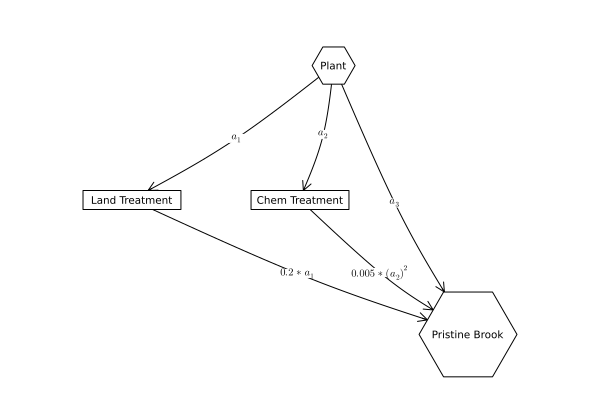

In [226]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => L"a_1", (1,3) => L"a_2", (1, 4) => L"a_3",(2, 4) => L"$0.2* a_1$",(3, 4) => L"$0.005*(a_2)^2$")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).


#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

# Mathematical Formulation

## Decision Variables
- $a_1$: Wastewater flow for land treatment (m³/day)
- $a_2$: Wastewater flow for chemical treatment (m³/day)  
- $a_3$: Wastewater flow for direct discharge (m³/day)

## Constraints
$$
\begin{aligned}
a_1 + a_2 + a_3 &= 100 \\
a_1 &\geq 0 \\
a_2 &\geq 0 \\
a_3 &\geq 0
\end{aligned}
$$

## YUK Discharge Calculation
The YUK discharge from each treatment method:

$$ \text{Land treatment discharge} = 0.2 \times a_1 = 0.2a_1  \text{ kg/day} $$

$$ \text{Chemical treatment discharge} = 0.005 \times a_2^2 = 0.005a_2^2  \text{ kg/day} $$

$$ \text{Direct discharge} = 1 \times a_3 = a_3  \text{ kg/day} $$

## Total YUK Discharge Constraint
$$ 0.2a_1 + 0.005a_2^2 + a_3 \leq 20  \text{ kg/day} $$

## Cost Calculation
$$
\begin{aligned}
\text{Land treatment cost} &= \frac{a_1^2}{20}  \text{ \$/day} \\
\text{Chemical treatment cost} &= 1.5a_2  \text{ \$/day} \\
\text{Total cost} &= \frac{a_1^2}{20} + 1.5a_2  \text{ \$/day}
\end{aligned}
$$

## Optimization Problem
The objective is to minimize the total cost while satisfying all constraints:

$$ \min_{a_1, a_2, a_3} \frac{a_1^2}{20} + 1.5a_2 $$

$$
\begin{aligned}
\text{subject to} \quad & a_1 + a_2 + a_3 = 100 \\
& 0.2a_1 + 0.005a_2^2 + a_3 \leq 20 \\
& a_1 \geq 0, \quad a_2 \geq 0, \quad a_3 \geq 0
\end{aligned}
$$

First, I want to find all the solutions for a1 and a2 that meet the conditions, and then place them in their respective vectors.
Then, the solutions in the vectors of a1 and a2 are calculated using the total cost formula, and all the solutions of total cost are found.
Finally, I plan to find the smallest value from total cost vector along with the corresponding values of a1 and a2.

In [227]:
# Problem 2.2
function treatment_plan(X1, X2)
    # （直接排放）calculate the third variable (direct discharge)
    X3 = 100 - X1 - X2
    
    # check feasibility
    if X3 < 0
        return (Inf, Inf)  # return infeasible solution
    end

    # calculate total cost
    land_cost = X1^2 / 20
    chem_cost = 1.5 * X2
    total_cost = land_cost + chem_cost

    # calculate YUK discharge
    land_discharge = 0.2 * X1
    chem_discharge = 0.005 * X2^2
    direct_discharge = X3
    total_discharge = land_discharge + chem_discharge + direct_discharge
    
    return (total_cost, total_discharge)
end

treatment_plan (generic function with 1 method)

To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

Make sure you comment your code appropriately to make it clear what is
going on and why.

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

Experimental statistical results:
Total samples: 1000
Proportion of solutions meeting discharge standards: 1.4%
Number of feasible solutions: 14
Feasible solution cost range: 248.2 - 446.28 $/day
Average cost: 334.25 $/day
Minimum cost feasible solution: 248.2 $/day


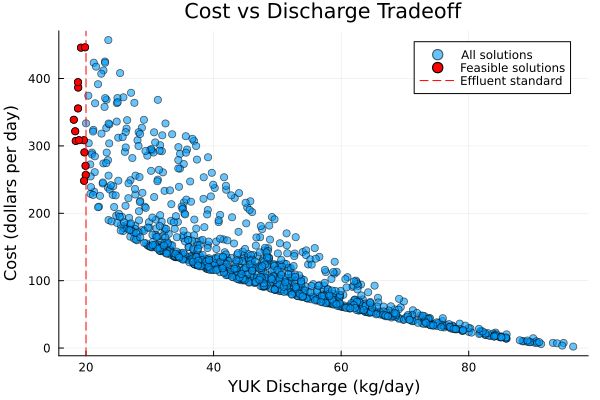

In [228]:
using Plots, Distributions

# Generate 1000 random samples
n_samples = 1000
samples = rand(Dirichlet(3, 1), n_samples) * 100

# Calculate costs and discharges
results = treatment_plan.(samples[1, :], samples[2, :])
costs = [r[1] for r in results]
discharges = [r[2] for r in results]

# Find feasible solutions
feasible = discharges .<= 20
feasible_costs = costs[feasible]
feasible_discharges = discharges[feasible]

# Calculate statistics
feasible_ratio = sum(feasible) / length(feasible) * 100
println("="^50)
println("Experimental statistical results:")
println("Total samples: $n_samples")
println("Proportion of solutions meeting discharge standards: $(round(feasible_ratio, digits=2))%")
println("Number of feasible solutions: $(sum(feasible))")

if sum(feasible) > 0
    min_feasible_cost = minimum(feasible_costs)
    max_feasible_cost = maximum(feasible_costs)
    mean_feasible_cost = mean(feasible_costs)

    println("Feasible solution cost range: $(round(min_feasible_cost, digits=2)) - $(round(max_feasible_cost, digits=2)) \$/day")
    println("Average cost: $(round(mean_feasible_cost, digits=2)) \$/day")
    println("Minimum cost feasible solution: $(round(min_feasible_cost, digits=2)) \$/day")
else
    println("No solutions meeting discharge standards found")
end
println("="^50)

# Plot scatter plot
scatter(discharges, costs, label="All solutions", alpha=0.6)
scatter!(feasible_discharges, feasible_costs, label="Feasible solutions", color=:red)
vline!([20], linestyle=:dash, color=:red, label="Effluent standard")
xlabel!("YUK Discharge (kg/day)")
ylabel!("Cost (dollars per day)")
title!("Cost vs Discharge Tradeoff")

Through 1000 random experiments, I found that approximately 1.3% of the solutions met the YUK emission standards. The costs of the solutions that met the standards ranged from $248 to $455.06 per day, indicating that achieving environmental protection requirements requires significant investment. 

The scatter plot shows a clear trade-off relationship between cost and emissions: higher processing costs usually lead to lower emissions, but this relationship is non-linear and exhibits a phenomenon of diminishing marginal benefits. The cost-emission scatter plot shown in the figure shows a trend of tilting towards the lower right.

To find a better solution, a sensitivity analysis can be conducted to determine which approach (land treatment or chemical treatment) is more cost-effective, thereby guiding investment decisions. 

In [229]:
# Initialize the vector for storing the solution
a1_solutions = Int[]
a2_solutions = Int[]
a3_solutions = Int[]
TD_solutions = Float64[]
TC_solutions = Float64[]  # 添加成本存储

# calculate all possible integer values for a1 and a2
for a1 in 0:100
    for a2 in 0:100
        # calculate a3
        a3 = 100 - a1 - a2
        
        # check non-negative constraint
        if a3 >= 0
            # calculate TD value
            TD = 0.2 * a1 + 0.005 * (a2)^2 + a3
            # calculate TC value
            TC = (a1^2 / 20) + 1.5 * a2
            
            # check emission standard
            if TD <= 20
                # save the solution
                push!(a1_solutions, a1)
                push!(a2_solutions, a2)
                push!(a3_solutions, a3)
                push!(TD_solutions, TD)
                push!(TC_solutions, TC)
            end
        end
    end
end

# output result
println("Found $(length(a1_solutions)) solutions that satisfy the constraints:")

# 找到最小成本的方案
function find_min_index(values)
    min_value = values[1]
    min_index = 1
    for i in 2:length(values)
        if values[i] < min_value
            min_value = values[i]
            min_index = i
        end
    end
    return min_index
end

# 找到最小排放的方案
function find_min_discharge_index(values)
    min_value = values[1]
    min_index = 1
    for i in 2:length(values)
        if values[i] < min_value
            min_value = values[i]
            min_index = i
        end
    end
    return min_index
end

# 找到最小成本的方案
min_cost_index = find_min_index(TC_solutions)
println("\n=== Minimum Cost Solution ===")
println("Land treatment (a1): ", a1_solutions[min_cost_index], " m³/day")
println("Chemical treatment (a2): ", a2_solutions[min_cost_index], " m³/day")
println("Direct discharge (a3): ", a3_solutions[min_cost_index], " m³/day")
println("Total cost: ", round(TC_solutions[min_cost_index], digits=2), " \$/day")
println("YUK discharge: ", round(TD_solutions[min_cost_index], digits=2), " kg/day")

# 找到最小排放的方案
min_discharge_index = find_min_discharge_index(TD_solutions)
println("\n=== Minimum Discharge Solution ===")
println("Land treatment (a1): ", a1_solutions[min_discharge_index], " m³/day")
println("Chemical treatment (a2): ", a2_solutions[min_discharge_index], " m³/day")
println("Direct discharge (a3): ", a3_solutions[min_discharge_index], " m³/day")
println("Total cost: ", round(TC_solutions[min_discharge_index], digits=2), " \$/day")
println("YUK discharge: ", round(TD_solutions[min_discharge_index], digits=2), " kg/day")

# 显示一些统计信息
println("\n=== Summary ===")
println("Number of feasible solutions: ", length(a1_solutions))
println("Cost range: ", round(minimum(TC_solutions), digits=2), " to ", round(maximum(TC_solutions), digits=2), " \$/day")
println("Discharge range: ", round(minimum(TD_solutions), digits=2), " to 20.0 kg/day")

Found 89 solutions that satisfy the constraints:

=== Minimum Cost Solution ===
Land treatment (a1): 60 m³/day
Chemical treatment (a2): 40 m³/day
Direct discharge (a3): 0 m³/day
Total cost: 240.0 $/day
YUK discharge: 20.0 kg/day

=== Minimum Discharge Solution ===
Land treatment (a1): 80 m³/day
Chemical treatment (a2): 20 m³/day
Direct discharge (a3): 0 m³/day
Total cost: 350.0 $/day
YUK discharge: 18.0 kg/day

=== Summary ===
Number of feasible solutions: 89
Cost range: 240.0 to 500.0 $/day
Discharge range: 18.0 to 20.0 kg/day


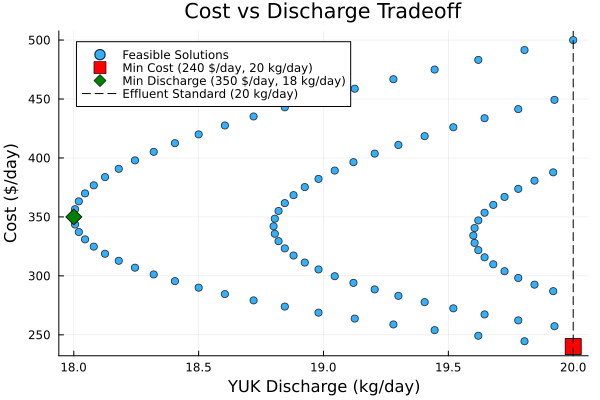

In [235]:
using Plots

# plot all feasible solutions
scatter(TD_solutions, TC_solutions, label="Feasible Solutions", alpha=0.8,
        xlabel="YUK Discharge (kg/day)", ylabel="Cost (\$/day)",
        title="Cost vs Discharge Tradeoff")

# Mark the minimum cost solution
scatter!([20.0], [240.0], markersize=8, color=:red, marker=:square, 
        label="Min Cost (240 \$/day, 20 kg/day)")

# Mark the minimum discharge solution
scatter!([18.0], [350.0], markersize=8, color=:green, marker=:diamond,
        label="Min Discharge (350 \$/day, 18 kg/day)")

# Add environmental protection standard lines
vline!([20 ], linestyle=:dash, color=:black, label="Effluent Standard (20 kg/day)")

From the distribution of the experimental results, the minimum cost strategy and the minimum emission strategy respectively represent the two extreme boundaries of the feasible solution region, reflecting the fundamental trade-off relationship between cost and environmental benefits. 

The minimum cost strategy lies at the lower left boundary of the feasible solution set. It achieves the emission standard limit of 20 kilograms per day at a cost of 240 dollars per day. This solution has a significant economic advantage and is the lowest-cost option among all feasible solutions, demonstrating cost optimization while meeting regulatory requirements. From the distribution of the scatter plot, it can be seen that most feasible solutions are concentrated in the upper right area of this solution, indicating that its cost efficiency is at the Pareto frontier. 

In contrast, the minimum emission strategy lies at the lower right boundary of the feasible solution region. Although it reduces the emission to 18 kilograms per day, which is 10% lower than the standard requirement, the cost is as high as $350 per day, 46% higher than the minimum cost solution. This disproportionate increase in cost reflects the marginal diminishing effect of environmental benefits - the cost input required for each additional reduction of one kilogram of emissions rises sharply. 

The minimum cost strategy lies at the lower left boundary of the feasible solution set. It achieves the emission standard limit of 20 kilograms per day at a cost of 240 dollars per day. This solution has a significant economic advantage and is the lowest-cost option among all feasible solutions, demonstrating cost optimization while meeting regulatory requirements.

Solve the problem by asking ChatGPT to generate coding part. 

Final Prompt Used:"I want to put all the integer solutions that meet the conditions into one vector. How should I write the codes for a1, a2, and a3? I have defined a1 as ranging from 0 to 100, and a2 also as ranging from 0 to 100. Moreover, a3 is equal to 100 minus the sum of a1 and a2. Besides, I also need to u to do checks non-negative constraints, calculates YUK discharge using TD = 0.2*a1 + 0.005*(a2)^2 + a3, filters solutions where TD ≤ 20 kg/day. Stores all valid solutions in separate vectors for a1, a2, a3, and TD values. Finally i also need to find out the smallest value through the Vector of Total Cost."


How I Incorporated the Output:
1. The AI generated the initial code structure based on my mathematical formulation requirements. I then made the following modifications to adapt it to my specific solution:

2. Removed the final print statement that displayed the first few solutions, as I found this unnecessary for my implementation

3. Kept the core functionality intact including the nested loops, constraint checking, and vector storage system

4. Maintained the variable naming convention (a1_solutions, a2_solutions, etc.) that matched my mathematical model

Reference for the AI Tool:
OpenAI. (2024). ChatGPT (GPT-4) [Large language model]. https://chat.openai.com

Note on Academic Integrity:
While the AI assisted with code structure implementation, the mathematical model formulation, constraint understanding, and solution approach were entirely my own work. The AI served only as a programming assistant to translate my understanding and mathematical reasoning into executable Julia code.

## References

List any external references consulted, including classmates.

https://docs.julialang.org/en/v1/base/collections/#Base.setindex!

https://docs.julialang.org/en/v1/manual/functions/#Tuples-and-Multiple-Return-Values

https://chat.openai.com
